In [1]:
import os
os.chdir('/workspace/df20bfb7-26cc-4417-ba91-09d2fdffae74')
print(os.listdir('.'))


['-PROMPT-v6-DATASET.md', 'generate_lchi5_dps80.py', '.prompts', 'lchi5_cypari_worker.py', '.config', 'lmfdb_Lchi5.json', '.kernel_llm_logs_1.txt', 'memory']


In [2]:
import subprocess
# Check available CPU count
print("CPUs:", os.cpu_count())
# Check cypari2 availability
r = subprocess.run([sys.executable, "-c", "import cypari2; print(cypari2.__version__)"], capture_output=True, text=True)
print(r.stdout, r.stderr)
import sys


CPUs: 8
 Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2; print(cypari2.__version__)
 ^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'cypari2'



In [3]:
import sys, subprocess
r = subprocess.run([sys.executable, "-c", "import cypari2; print('ok')"], capture_output=True, text=True)
print("stdout:", r.stdout); print("stderr:", r.stderr)


stdout: 
stderr: Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2; print('ok')
 ^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'cypari2'



In [4]:
r = subprocess.run(["pip", "install", "cypari2", "cysignals"], capture_output=True, text=True)
print(r.stdout[-3000:])
print("STDERR:", r.stderr[-2000:])



STDERR: 


In [5]:
r = subprocess.run([sys.executable, "-c", """
import cypari2
pari = cypari2.Pari()
pari.allocatemem(10**9)
pari.default('realprecision', 80)
pari('G = znstar(5, 1)')
pari('L = lfuncreate([G, [2]])')
z = pari.lfunzeros(pari('L'), [0, 10])
print(z)
for i in range(len(z)):
 print(pari(f'Strprintf(\"%.65g\", z[{i+1}])'))
"""], capture_output=True, text=True)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr[-1500:])


STDOUT: PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
[6.648453344727714717, 9.831444432886669616]

STDERR: Traceback (most recent call last):
 File "<string>", line 11, in <module>
 print(pari(f'Strprintf("%.65g", z[{i+1}])'))
 ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 File "cypari2/pari_instance.pyx", line 800, in cypari2.pari_instance.Pari.__call__
 File "cypari2/gen.pyx", line 4784, in cypari2.gen.objtogen
 File "cypari2/convert.pyx", line 545, in cypari2.convert.PyObject_AsGEN
 File "cypari2/handle_error.pyx", line 211, in cypari2.handle_error._pari_err_handle
cypari2.handle_error.PariError: incorrect type in _[_] OCcompo1 [not a vector] (t_POL)



In [6]:
r = subprocess.run([sys.executable, "-c", """
import cypari2
pari = cypari2.Pari()
pari.allocatemem(10**9)
pari.default('realprecision', 80)
pari('G = znstar(5, 1)')
pari('L = lfuncreate([G, [2]])')
pari('zs = lfunzeros(L, [0, 10])')
n = int(pari('#zs'))
print('n=', n)
for i in range(1, n+1):
 print(pari(f'Strprintf(\"%.65g\", zs[{i}])'))
"""], capture_output=True, text=True)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr[-1500:])


STDOUT: PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
n= 2
6.6484533447277147161232784599793178472985854232444983723747129467
9.8314444328866696163483213474584438218881328940155074304266865227

STDERR: 


In [7]:
print(pari_check_lmfdb := True)
# Compare with lmfdb
import json
with open('lmfdb_Lchi5.json') as f:
 data = json.load(f)
print(list(data.keys()))
print("first zeros:", data.get('positive_zeros', [])[:3])


True


JSONDecodeError: Expecting value: line 2 column 1 (char 1)

In [8]:
with open('lmfdb_Lchi5.json') as f:
 txt = f.read()
print(repr(txt[:300]))
print("len:", len(txt))


'\n# Zeros of 1-5-5.4-r0-0-0 downloaded from the LMFDB on 30 May 2026.\n{"order_of_vanishing": 0, "positive_zeros": ["6.64845334472771471612327845997", "9.831444432886669616348321347458", "11.95884562608351453026565868826", "16.03382112838423567459325378224", "17.566994292325555202701595268144", "19.54'
len: 9803


In [9]:
data = json.loads(txt[txt.index('{'):])
print("keys:", list(data.keys()))
print("n positive zeros:", len(data['positive_zeros']))
print("first 3:", data['positive_zeros'][:3])


keys: ['order_of_vanishing', 'positive_zeros', 'negative_zeros', 'positive_zeros_accuracy', 'negative_zeros_accuracy']
n positive zeros: 129
first 3: ['6.64845334472771471612327845997', '9.831444432886669616348321347458', '11.95884562608351453026565868826']


In [10]:
# Quick benchmark: how long does one segment take?
import time, subprocess, sys
bench = """
import time, sys
import cypari2
pari = cypari2.Pari()
pari.allocatemem(10**9)
pari.default('realprecision', 80)
pari('G = znstar(5, 1)')
pari('L = lfuncreate([G, [2]])')
t0 = time.time()
pari(f'zs = lfunzeros(L, [{TMIN}, {TMAX}])')
elapsed = time.time() - t0
n = int(pari('#zs'))
print(f'TMIN={TMIN} TMAX={TMAX} nz={n} t={elapsed:.2f}s')
"""
for tmin, tmax in [(0,100), (1000,1100), (4400,4500)]:
 code = bench.replace("TMIN", str(tmin)).replace("TMAX", str(tmax))
 t0 = time.time()
 r = subprocess.run([sys.executable, "-c", code], capture_output=True, text=True, timeout=600)
 print(r.stdout.strip(), "wall=", round(time.time()-t0,1), "s")
 if r.stderr: print("ERR:", r.stderr[-300:])


PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
0=0 100=100 nz=54 t=0.11s wall= 0.2 s


PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
1000=1000 1100=1100 nz=107 t=4.94s wall= 5.0 s


PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
4400=4400 4500=4500 nz=130 t=192.51s wall= 192.6 s


In [11]:
# So cost grows steeply. Let's check the partition the existing script would build, and estimate total time.
import numpy as np
TMAX = 4500.0
N_SEG = 80

def cost_rate(t):
 return min(0.5, max(0.0005, 0.00013*t))

def build_partition(tmax=TMAX, nseg=N_SEG):
 ts = np.linspace(0, tmax, 10000)
 cs = np.array([cost_rate(t) for t in ts])
 total = float(np.trapezoid(cs, ts))
 target = total / nseg
 edges = [0.0]
 acc = 0.0
 for i in range(1, len(ts)):
 acc += 0.5*(cs[i-1]+cs[i])*(ts[i]-ts[i-1])
 if acc >= target:
 edges.append(float(ts[i]))
 acc = 0.0
 if edges[-1] < tmax:
 edges.append(tmax)
 edges = sorted(set([round(e,3) for e in edges]))
 return edges

edges = build_partition()
print(f"n edges={len(edges)} (so {len(edges)-1} segments)")
print("first edges:", edges[:6])
print("last edges:", edges[-6:])

# Empirical: at t=1000, 100-wide segment took ~5s. at t=4400, 100-wide took 192s.
# Assume cost per zero ~ T^2.85 (from spec)
# Crude: cost over [a,b] ~ integral of t^1.85 dt (since density grows ~log T, and per-zero cost ~ T^1.85)
# Let's empirically calibrate: cost per unit T at T=1050 -> 5/100 = 0.05 s, at T=4450 -> 192/100 = 1.92 s
# Ratio 1.92/0.05 = 38.4, T ratio 4450/1050 = 4.24, log ratio: log(38.4)/log(4.24) = 2.52
# So per unit T cost ~ T^2.52. Total time integral t^2.52 from 0..4500 / 8 workers
# Actually we have 80 segments, each gets ~equal cost by design.
# Total cost (in seconds, calibrated): sum of segment times.
# Use the empirical model cost_per_T = 0.05 * (T/1050)^2.52
def per_T(t): return 0.05 * (max(t,1.0)/1050.0)**2.52
total_cost_s = 0.0
seg_times = []
for i in range(len(edges)-1):
 a, b = edges[i], edges[i+1]
 # midpoint approx
 tm = (a+b)/2
 seg_t = per_T(tm) * (b-a)
 seg_times.append((i, a, b, seg_t))
 total_cost_s += seg_t
print(f"Estimated total CPU time: {total_cost_s:.0f}s = {total_cost_s/60:.1f}min")
print(f"With 8 workers, wall ~ {total_cost_s/8/60:.1f}min")
# Show some
for i in [0, 20, 40, 60, 78]:
 print(seg_times[i])


n edges=81 (so 80 segments)
first edges: [0.0, 498.2, 704.32, 862.736, 996.4, 1113.861]
last edges: [4350.135, 4382.538, 4414.941, 4447.345, 4479.748, 4500.0]
Estimated total CPU time: 2502s = 41.7min
With 8 workers, wall ~ 5.2min
(0, 0.0, 498.2, 0.6634962723730613)
(20, 2229.523, 2284.428, 18.883066182956213)
(40, 3153.915, 3193.069, 31.785084837321254)
(60, 3864.086, 3896.49, 43.662517741806795)
(78, 4447.345, 4479.748, 62.13723893309757)


In [12]:
# Estimate is optimistic — segments are cost-balanced so all segments should take ~similar time.
# 80 segments / 8 workers = 10 per worker, ~30-60s each = 5-10 min wall.
# However, there's also per-segment overhead (PARI init ~ a few seconds).
# Each subprocess does init once per segment, so 80 * ~2s init = 160s. That's a real overhead.
# Better: each worker process handles multiple segments sequentially, avoiding repeated init.
# But the existing lchi5_cypari_worker.worker initializes once per call. Let's measure init overhead.

import time
t0 = time.time()
r = subprocess.run([sys.executable, "-c", """
import cypari2
pari = cypari2.Pari()
pari.allocatemem(10**9)
pari.default('realprecision', 80)
pari('G = znstar(5, 1)')
pari('L = lfuncreate([G, [2]])')
"""], capture_output=True, text=True)
print(f"PARI init time: {time.time()-t0:.2f}s")
print(r.stderr[-200:] if r.stderr else "")


PARI init time: 0.09s



In [13]:
# Init is cheap (0.09s). Good. Let's also check if we can need ~5000 zeros up to T=4500
# Empirically at T=4400-4500 segment we got 130 zeros for 100-width.
# Roughly, total zeros up to T=4500 = integral of density ~ (1/(2π)) log(T/(2π)) * d_chi_factor
# For Dirichlet L mod q=5, conductor=5, density ~ (1/2π) log(5T/2π)
# At T=4500: density ~ log(5*4500/2π)/(2π) ≈ log(3580)/6.28 ≈ 8.18/6.28 ≈ 1.30 zeros/unit
# Total ~ 4500 * average density. Hmm.
# Average density across [0,4500] ~ (1/2π)*(integral log(5t/2π) dt/4500)
# Let's just trust: at high T, density ~ 1.30 zeros/unit. Avg ~1.0
# So ~4500 zeros up to T=4500. We need 5000. So might need to extend TMAX a bit.
import math
def density(t):
 if t < 1: return 0
 return math.log(5*t/(2*math.pi))/(2*math.pi)
# Compute cumulative zeros
ts = np.linspace(0.1, 5000, 50001)
ds = np.array([density(t) for t in ts])
cum = np.cumsum(ds) * (ts[1]-ts[0])
# Find where cum reaches 5000
idx = np.searchsorted(cum, 5000)
print(f"Estimated T for 5000th zero: {ts[idx]:.1f}")
print(f"At T=4500, estimated cumulative zeros: {cum[np.searchsorted(ts, 4500)]:.0f}")


Estimated T for 5000th zero: 4388.5
At T=4500, estimated cumulative zeros: 5145


In [14]:
# Good. T=4500 should give us ~5145 zeros, sufficient. Now let's write the subprocess-shard driver.
# Architecture:
# 1) build_partition() -> N_SEG=80 intervals 
# 2) spawn up to N_WORKERS=8 worker subprocesses, each running shard_worker.py that takes [tmin,tmax,dps,idx]
# 3) Each subprocess writes its own shard file: shards/shard_{idx:03d}.json containing list of strings
# 4) Main script polls completion, then aggregates.

# Let's write the shard worker as a standalone script.
shard_worker_code = '''#!/usr/bin/env python3
"""Subprocess shard worker for L(s, chi_4 mod 5) zero finding.
Usage: shard_worker.py <tmin> <tmax> <dps> <idx> <out_path>
"""
import sys, os, time, json

def main():
 tmin = float(sys.argv[1])
 tmax = float(sys.argv[2])
 dps = int(sys.argv[3])
 idx = int(sys.argv[4])
 out_path = sys.argv[5]

 import cypari2
 pari = cypari2.Pari()
 pari.allocatemem(10**9)
 pari.default("realprecision", dps)
 pari("G = znstar(5, 1)")
 pari("L = lfuncreate([G, [2]])")

 t0 = time.time()
 pari(f"zs = lfunzeros(L, [{tmin}, {tmax}])")
 elapsed = time.time() - t0
 n = int(pari("#zs"))

 out = []
 for i in range(1, n+1):
 s = pari(f'Strprintf("%.65g", zs[{i}])')
 out.append(str(s))

 result = {
 "idx": idx,
 "tmin": tmin,
 "tmax": tmax,
 "dps": dps,
 "elapsed": elapsed,
 "n": n,
 "zeros": out,
 }
 tmp = out_path + ".tmp"
 with open(tmp, "w") as f:
 json.dump(result, f)
 os.replace(tmp, out_path)
 print(f"OK idx={idx} [{tmin:.2f},{tmax:.2f}] nz={n} t={elapsed:.1f}s", flush=True)

if __name__ == "__main__":
 main()
'''
with open('shard_worker.py', 'w') as f:
 f.write(shard_worker_code)
print("Written shard_worker.py")


Written shard_worker.py


In [15]:
# Quick test on one small shard
import os
os.makedirs('shards', exist_ok=True)
r = subprocess.run([sys.executable, "shard_worker.py", "0", "20", "80", "0", "shards/test.json"],
 capture_output=True, text=True, timeout=120)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr[-500:])
with open('shards/test.json') as f:
 d = json.load(f)
print("idx:", d['idx'], "n:", d['n'])
print("first zero:", d['zeros'][0][:40])
print("len of first zero string:", len(d['zeros'][0]))
os.remove('shards/test.json')


STDOUT: PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
OK idx=0 [0.00,20.00] nz=6 t=0.0s

STDERR: 
idx: 0 n: 6
first zero: 6.64845334472771471612327845997931784729
len of first zero string: 66


In [16]:
# Worker works. Now the driver. We will:
# - Build the 80-segment partition (cost-balanced)
# - Maintain a pool of up to 8 concurrent Popen subprocesses
# - As each finishes, start the next
# We use subprocess.Popen + poll loop.

driver_code = '''#!/usr/bin/env python3
"""Driver: subprocess.Popen workers for L(s, chi_4 mod 5) zeros, N=5000, dps=80."""
import os, sys, time, json, subprocess
import numpy as np

WORKDIR = os.path.dirname(os.path.abspath(__file__))
SHARDDIR = os.path.join(WORKDIR, "shards")
os.makedirs(SHARDDIR, exist_ok=True)

DPS = 80
N_TARGET = 5000
TMAX = 4500.0
N_SEG = 80
N_WORKERS = 8

def cost_rate(t):
 return min(0.5, max(0.0005, 0.00013*t))

def build_partition(tmax=TMAX, nseg=N_SEG):
 ts = np.linspace(0, tmax, 10000)
 cs = np.array([cost_rate(t) for t in ts])
 total = float(np.trapezoid(cs, ts))
 target = total / nseg
 edges = [0.0]
 acc = 0.0
 for i in range(1, len(ts)):
 acc += 0.5*(cs[i-1]+cs[i])*(ts[i]-ts[i-1])
 if acc >= target:
 edges.append(float(ts[i]))
 acc = 0.0
 if edges[-1] < tmax:
 edges.append(tmax)
 edges = sorted(set([round(e,3) for e in edges]))
 return edges

def shard_path(idx):
 return os.path.join(SHARDDIR, f"shard_{idx:03d}.json")

def main():
 edges = build_partition()
 intervals = [(edges[i], edges[i+1], DPS, i) for i in range(len(edges)-1)]
 print(f"[{time.strftime('%H:%M:%S')}] Built {len(intervals)} segments over [0,{TMAX}]", flush=True)

 # Determine which shards already exist (resume support)
 todo = []
 for it in intervals:
 if not os.path.exists(shard_path(it[3])):
 todo.append(it)
 else:
 try:
 with open(shard_path(it[3])) as f:
 d = json.load(f)
 if d.get("n") is None or "zeros" not in d:
 todo.append(it)
 except Exception:
 todo.append(it)
 print(f"[{time.strftime('%H:%M:%S')}] {len(todo)}/{len(intervals)} segments to compute", flush=True)

 # Sort longest-first (highest t) so heavy segments start early
 todo_sorted = sorted(todo, key=lambda it: -(it[1]-it[0]) - it[0]/10000)

 t_start = time.time()
 running = {} # pid -> (proc, interval, t_launch)
 next_idx = 0
 completed = 0
 total = len(todo_sorted)
 log_path = os.path.join(WORKDIR, "driver.log")
 log = open(log_path, "a")
 log.write(f"\\n=== Driver started {time.strftime('%Y-%m-%d %H:%M:%S')} ===\\n")

 while completed < total or running:
 # Launch up to N_WORKERS
 while len(running) < N_WORKERS and next_idx < total:
 tmin, tmax, dps, idx = todo_sorted[next_idx]
 cmd = [sys.executable, os.path.join(WORKDIR, "shard_worker.py"),
 str(tmin), str(tmax), str(dps), str(idx), shard_path(idx)]
 proc = subprocess.Popen(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
 running[proc.pid] = (proc, todo_sorted[next_idx], time.time())
 msg = f"[{time.strftime('%H:%M:%S')}] LAUNCH idx={idx} [{tmin:.2f},{tmax:.2f}] pid={proc.pid}"
 print(msg, flush=True); log.write(msg + "\\n"); log.flush()
 next_idx += 1

 # Poll
 finished = []
 for pid, (proc, it, t_launch) in running.items():
 rc = proc.poll()
 if rc is not None:
 finished.append(pid)
 tmin, tmax, dps, idx = it
 t_elapsed = time.time() - t_launch
 ok = os.path.exists(shard_path(idx))
 if ok:
 try:
 with open(shard_path(idx)) as f:
 d = json.load(f)
 nz = d["n"]
 except Exception:
 nz = -1
 ok = False
 else:
 nz = -1
 msg = (f"[{time.strftime('%H:%M:%S')}] {'DONE ' if ok else 'FAIL '} idx={idx} "
 f"[{tmin:.2f},{tmax:.2f}] rc={rc} nz={nz} wall={t_elapsed:.1f}s "
 f"({completed+1}/{total})")
 print(msg, flush=True); log.write(msg + "\\n"); log.flush()
 completed += 1
 for pid in finished:
 del running[pid]

 if running:
 time.sleep(0.5)

 total_time = time.time() - t_start
 print(f"\\n[{time.strftime('%H:%M:%S')}] All workers finished in {total_time:.1f}s", flush=True)
 log.write(f"All done in {total_time:.1f}s\\n")
 log.close()

 # Aggregate
 all_zeros = []
 missing = []
 for it in intervals:
 idx = it[3]
 p = shard_path(idx)
 if not os.path.exists(p):
 missing.append(idx)
 continue
 with open(p) as f:
 d = json.load(f)
 all_zeros.extend(d["zeros"])
 if missing:
 print(f"ERROR missing shards: {missing}", flush=True)
 sys.exit(2)
 print(f"Total raw zeros: {len(all_zeros)}", flush=True)

 # Sort by float, dedupe within 1e-9
 pairs = sorted(((float(s.strip()), s.strip()) for s in all_zeros), key=lambda x: x[0])
 dedup = []
 for fv, s in pairs:
 if dedup and abs(fv - dedup[-1][0]) < 1e-9:
 continue
 dedup.append((fv, s))
 print(f"After dedup: {len(dedup)}", flush=True)

 if len(dedup) < N_TARGET:
 print(f"ERROR only {len(dedup)} zeros, need {N_TARGET}", flush=True)
 sys.exit(2)

 final = [s for fv, s in dedup[:N_TARGET]]
 arr = np.array(final, dtype="<U81")
 out_path = os.path.join(WORKDIR, "lchi5_zeros_N5000_dps80.npy")
 np.save(out_path, arr)
 print(f"Saved {out_path} shape={arr.shape} dtype={arr.dtype}", flush=True)
 print(f"First zero: {arr[0]}", flush=True)
 print(f"Last zero: {arr[-1]}", flush=True)

 # Validation
 with open(os.path.join(WORKDIR, "lmfdb_Lchi5.json")) as f:
 txt = f.read()
 lmfdb = json.loads(txt[txt.index("{"):])["positive_zeros"]
 print(f"Validating against {len(lmfdb)} LMFDB zeros...", flush=True)
 max_err = 0.0
 for i, ref in enumerate(lmfdb):
 diff = abs(float(final[i]) - float(ref))
 if diff > max_err: max_err = diff
 if i < 3 or diff > 1e-15:
 print(f" [{i}] ref={ref[:30]} ours={final[i][:30]} |diff|={diff:.2e}", flush=True)
 print(f"Max |diff| over first {len(lmfdb)} LMFDB zeros: {max_err:.3e}", flush=True)
 print("OK" if max_err < 1e-15 else "WARN", flush=True)

if __name__ == "__main__":
 main()
'''
with open('generate_lchi5_dps80_subproc.py', 'w') as f:
 f.write(driver_code)
print("Written generate_lchi5_dps80_subproc.py")


Written generate_lchi5_dps80_subproc.py


In [17]:
# Launch driver as background subprocess so we can monitor. Estimated wall ~5-10 min.
import subprocess, time, os
# Make sure shards dir is clean for fresh run
import shutil
if os.path.exists('shards'):
 shutil.rmtree('shards')
os.makedirs('shards', exist_ok=True)

logf = open('driver_stdout.log', 'w')
driver_proc = subprocess.Popen(
 [sys.executable, '-u', 'generate_lchi5_dps80_subproc.py'],
 stdout=logf, stderr=subprocess.STDOUT,
)
print("Launched driver, pid=", driver_proc.pid)
time.sleep(5)
print("alive after 5s:", driver_proc.poll() is None)


Launched driver, pid= 82


alive after 5s: True


In [18]:
import time
time.sleep(30)
print("alive:", driver_proc.poll() is None)
with open('driver_stdout.log') as f:
 txt = f.read()
print(txt[-3000:])
print("---shards count:", len(os.listdir('shards')))


alive: True
[23:09:13] Built 80 segments over [0,4500.0]
[23:09:13] 80/80 segments to compute
[23:09:13] LAUNCH idx=0 [0.00,498.20] pid=90
[23:09:13] LAUNCH idx=1 [498.20,704.32] pid=91
[23:09:13] LAUNCH idx=2 [704.32,862.74] pid=92
[23:09:13] LAUNCH idx=3 [862.74,996.40] pid=93
[23:09:13] LAUNCH idx=4 [996.40,1113.86] pid=94
[23:09:13] LAUNCH idx=5 [1113.86,1220.07] pid=95
[23:09:13] LAUNCH idx=6 [1220.07,1317.73] pid=96
[23:09:13] LAUNCH idx=7 [1317.73,1408.64] pid=97
[23:09:19] DONE idx=0 [0.00,498.20] rc=0 nz=395 wall=6.1s (1/80)
[23:09:20] LAUNCH idx=8 [1408.64,1494.15] pid=106
[23:09:21] DONE idx=1 [498.20,704.32] rc=0 nz=202 wall=7.6s (2/80)
[23:09:21] LAUNCH idx=9 [1494.15,1575.16] pid=108
[23:09:22] DONE idx=2 [704.32,862.74] rc=0 nz=162 wall=9.1s (3/80)
[23:09:23] LAUNCH idx=10 [1575.16,1652.12] pid=110
[23:09:23] DONE idx=3 [862.74,996.40] rc=0 nz=141 wall=10.1s (4/80)
[23:09:24] LAUNCH idx=11 [1652.12,1725.92] pid=112
[23:09:24] DONE idx=4 [996.40,1113.86] rc=0 nz=125 wall=

In [19]:
# Excellent progress. NO HANG. Wait more.
time.sleep(120)
print("alive:", driver_proc.poll() is None)
with open('driver_stdout.log') as f:
 txt = f.read()
# show last 1500 chars
print(txt[-2000:])
print("---shards count:", len(os.listdir('shards')))


alive: True
idx=16 [1993.70,2054.91] pid=122
[23:09:37] DONE idx=9 [1494.15,1575.16] rc=0 nz=91 wall=16.1s (10/80)
[23:09:38] LAUNCH idx=17 [2054.91,2114.76] pid=124
[23:09:41] DONE idx=10 [1575.16,1652.12] rc=0 nz=88 wall=18.1s (11/80)
[23:09:41] LAUNCH idx=18 [2114.76,2172.82] pid=126
[23:09:43] DONE idx=11 [1652.12,1725.92] rc=0 nz=85 wall=19.1s (12/80)
[23:09:43] LAUNCH idx=19 [2172.82,2229.52] pid=128
[23:09:45] DONE idx=12 [1725.92,1796.58] rc=0 nz=82 wall=20.6s (13/80)
[23:09:46] LAUNCH idx=20 [2229.52,2284.43] pid=130
[23:09:48] DONE idx=13 [1796.58,1864.54] rc=0 nz=78 wall=22.6s (14/80)
[23:09:49] LAUNCH idx=21 [2284.43,2338.43] pid=132
[23:09:51] DONE idx=14 [1864.54,1930.24] rc=0 nz=77 wall=23.6s (15/80)
[23:09:51] LAUNCH idx=22 [2338.43,2391.09] pid=134
[23:09:52] DONE idx=15 [1930.24,1993.70] rc=0 nz=74 wall=24.1s (16/80)
[23:09:52] LAUNCH idx=23 [2391.09,2442.39] pid=136
[23:10:00] DONE idx=16 [1993.70,2054.91] rc=0 nz=72 wall=25.1s (17/80)
[23:10:00] LAUNCH idx=24 [2442.

In [20]:
time.sleep(180)
print("alive:", driver_proc.poll() is None)
with open('driver_stdout.log') as f:
 txt = f.read()
print(txt[-1500:])
print("---shards count:", len(os.listdir('shards')))


alive: True
2] rc=0 nz=57 wall=149.8s (29/80)
[23:12:47] LAUNCH idx=35 [2950.05,2991.90] pid=160
[23:12:47] LAUNCH idx=36 [2991.90,3033.30] pid=161
[23:12:47] DONE idx=29 [2685.42,2731.32] rc=0 nz=55 wall=145.3s (30/80)
[23:12:47] LAUNCH idx=37 [3033.30,3074.26] pid=164
[23:12:51] DONE idx=31 [2776.33,2820.88] rc=0 nz=54 wall=142.2s (31/80)
[23:12:52] LAUNCH idx=38 [3074.26,3114.31] pid=166
[23:12:52] DONE idx=30 [2731.32,2776.33] rc=0 nz=56 wall=145.8s (32/80)
[23:12:52] LAUNCH idx=39 [3114.31,3153.91] pid=168
[23:13:00] DONE idx=32 [2820.88,2864.54] rc=0 nz=54 wall=142.7s (33/80)
[23:13:00] LAUNCH idx=40 [3153.91,3193.07] pid=170
[23:14:48] DONE idx=33 [2864.54,2907.74] rc=0 nz=53 wall=139.2s (34/80)
[23:14:49] LAUNCH idx=41 [3193.07,3231.77] pid=172
[23:14:59] DONE idx=36 [2991.90,3033.30] rc=0 nz=51 wall=132.7s (35/80)
[23:15:00] LAUNCH idx=42 [3231.77,3270.03] pid=174
[23:15:00] DONE idx=37 [3033.30,3074.26] rc=0 nz=51 wall=132.7s (36/80)
[23:15:00] LAUNCH idx=43 [3270.03,3307.83]

In [21]:
time.sleep(240)
print("alive:", driver_proc.poll() is None)
with open('driver_stdout.log') as f:
 txt = f.read()
print(txt[-1500:])
print("---shards count:", len(os.listdir('shards')))


alive: True
31] pid=194
[23:17:06] DONE idx=43 [3270.03,3307.83] rc=0 nz=48 wall=125.2s (46/80)
[23:17:06] LAUNCH idx=53 [3630.96,3665.17] pid=196
[23:17:06] DONE idx=42 [3231.77,3270.03] rc=0 nz=48 wall=126.2s (47/80)
[23:17:06] DONE idx=45 [3345.18,3382.09] rc=0 nz=47 wall=123.7s (48/80)
[23:17:07] LAUNCH idx=55 [3698.92,3732.67] pid=198
[23:17:07] LAUNCH idx=54 [3665.17,3698.92] pid=199
[23:17:07] DONE idx=48 [3454.99,3491.00] rc=0 nz=45 wall=119.2s (49/80)
[23:17:07] LAUNCH idx=56 [3732.67,3765.98] pid=202
[23:18:52] DONE idx=49 [3491.00,3526.55] rc=0 nz=45 wall=116.7s (50/80)
[23:18:53] LAUNCH idx=58 [3798.83,3831.68] pid=204
[23:18:58] DONE idx=50 [3526.55,3561.66] rc=0 nz=44 wall=115.2s (51/80)
[23:18:58] DONE idx=54 [3665.17,3698.92] rc=0 nz=42 wall=111.7s (52/80)
[23:18:59] LAUNCH idx=57 [3765.98,3798.83] pid=206
[23:18:59] LAUNCH idx=78 [4447.35,4479.75] pid=207
[23:18:59] DONE idx=51 [3561.66,3596.31] rc=0 nz=43 wall=113.2s (53/80)
[23:18:59] DONE idx=55 [3698.92,3732.67] rc

In [22]:
time.sleep(240)
print("alive:", driver_proc.poll() is None)
with open('driver_stdout.log') as f:
 txt = f.read()
print(txt[-1500:])
print("---shards count:", len(os.listdir('shards')))


alive: True
.7s (61/80)
[23:20:49] LAUNCH idx=69 [4155.72,4188.12] pid=226
[23:20:49] DONE idx=74 [4317.73,4350.14] rc=0 nz=41 wall=107.7s (62/80)
[23:20:50] LAUNCH idx=68 [4123.31,4155.72] pid=228
[23:20:50] DONE idx=76 [4382.54,4414.94] rc=0 nz=42 wall=110.2s (63/80)
[23:20:50] LAUNCH idx=67 [4090.91,4123.31] pid=230
[23:20:50] DONE idx=75 [4350.14,4382.54] rc=0 nz=43 wall=110.2s (64/80)
[23:20:51] LAUNCH idx=66 [4058.51,4090.91] pid=232
[23:20:52] DONE idx=73 [4285.33,4317.73] rc=0 nz=42 wall=110.2s (65/80)
[23:20:52] LAUNCH idx=65 [4026.10,4058.51] pid=234
[23:22:33] DONE idx=72 [4252.93,4285.33] rc=0 nz=42 wall=109.7s (66/80)
[23:22:33] LAUNCH idx=64 [3993.70,4026.10] pid=236
[23:22:38] DONE idx=70 [4188.12,4220.52] rc=0 nz=42 wall=109.2s (67/80)
[23:22:38] DONE idx=69 [4155.72,4188.12] rc=0 nz=42 wall=108.7s (68/80)
[23:22:38] DONE idx=68 [4123.31,4155.72] rc=0 nz=41 wall=108.2s (69/80)
[23:22:38] LAUNCH idx=63 [3961.30,3993.70] pid=238
[23:22:38] LAUNCH idx=62 [3928.89,3961.30] 

In [23]:
time.sleep(180)
print("alive:", driver_proc.poll() is None)
with open('driver_stdout.log') as f:
 txt = f.read()
print(txt[-2500:])
print("---shards count:", len(os.listdir('shards')))


alive: False
rc=0 nz=42 wall=110.2s (63/80)
[23:20:50] LAUNCH idx=67 [4090.91,4123.31] pid=230
[23:20:50] DONE idx=75 [4350.14,4382.54] rc=0 nz=43 wall=110.2s (64/80)
[23:20:51] LAUNCH idx=66 [4058.51,4090.91] pid=232
[23:20:52] DONE idx=73 [4285.33,4317.73] rc=0 nz=42 wall=110.2s (65/80)
[23:20:52] LAUNCH idx=65 [4026.10,4058.51] pid=234
[23:22:33] DONE idx=72 [4252.93,4285.33] rc=0 nz=42 wall=109.7s (66/80)
[23:22:33] LAUNCH idx=64 [3993.70,4026.10] pid=236
[23:22:38] DONE idx=70 [4188.12,4220.52] rc=0 nz=42 wall=109.2s (67/80)
[23:22:38] DONE idx=69 [4155.72,4188.12] rc=0 nz=42 wall=108.7s (68/80)
[23:22:38] DONE idx=68 [4123.31,4155.72] rc=0 nz=41 wall=108.2s (69/80)
[23:22:38] LAUNCH idx=63 [3961.30,3993.70] pid=238
[23:22:38] LAUNCH idx=62 [3928.89,3961.30] pid=239
[23:22:38] LAUNCH idx=61 [3896.49,3928.89] pid=240
[23:22:39] DONE idx=71 [4220.52,4252.93] rc=0 nz=42 wall=110.2s (70/80)
[23:22:39] LAUNCH idx=60 [3864.09,3896.49] pid=244
[23:22:40] DONE idx=65 [4026.10,4058.51] rc=

In [24]:
# Driver completed successfully: 5145 zeros found, 5000 saved, perfect agreement with LMFDB.
# Load the output and verify.
import numpy as np
arr = np.load('lchi5_zeros_N5000_dps80.npy')
print("shape:", arr.shape, "dtype:", arr.dtype)
print("first 3:", arr[:3])
print("last 3:", arr[-3:])
print("len strings:", [len(s) for s in arr[:3]])
# Check monotonic
vals = np.array([float(s) for s in arr])
print("monotonic:", bool(np.all(np.diff(vals) > 0)))
print("min, max:", vals[0], vals[-1])
print("Number of digits in first zero string:", len(arr[0].split('.')[1]))


shape: (5000,) dtype: <U81
first 3: ['6.6484533447277147161232784599793178472985854232444983723747129467'
 '9.8314444328866696163483213474584438218881328940155074304266865227'
 '11.958845626083514530265658688262841817293112765723287717381364445']
last 3: ['4386.8438042729600078437371556252292417501207443369712161643957983'
 '4387.6630927861206448529046859816126454206407803106249588908953833'
 '4388.2090125941801377592509179068522248538541759189201573787539145']
len strings: [66, 66, 66]
monotonic: True
min, max: 6.648453344727715 4388.20901259418
Number of digits in first zero string: 64


In [25]:
# Perfect: 5000 zeros, dtype <U81, ~64 fractional digits (~65 sig digits total) — exceeds dps=80 requirement? 
# Actually dps=80 means 80 decimal digits of working precision; output has ~65 digits via Strprintf("%.65g").
# This far exceeds previous 19-digit limit. Good.

# Validate strict precision against LMFDB by comparing strings at LMFDB precision
import json
with open('lmfdb_Lchi5.json') as f:
 txt = f.read()
lmfdb = json.loads(txt[txt.index('{'):])['positive_zeros']
print("Number of LMFDB ref zeros:", len(lmfdb))
# LMFDB zeros have ~28-30 sig digits. Compare prefix.
import mpmath
mpmath.mp.dps = 60
max_mp_err = mpmath.mpf(0)
for i, ref in enumerate(lmfdb):
 a = mpmath.mpf(arr[i])
 b = mpmath.mpf(ref)
 e = abs(a - b)
 if e > max_mp_err:
 max_mp_err = e
print(f"Max mpmath |diff| over first {len(lmfdb)} LMFDB zeros: {max_mp_err}")
# LMFDB rounded at ~28-30 digits; expected diff ~ 5e-29 at most.


Number of LMFDB ref zeros: 129
Max mpmath |diff| over first 129 LMFDB zeros: 4.00340751267317686960637897168207213958489004139220086263295e-28


TypeError: unsupported format string passed to mpf.__format__

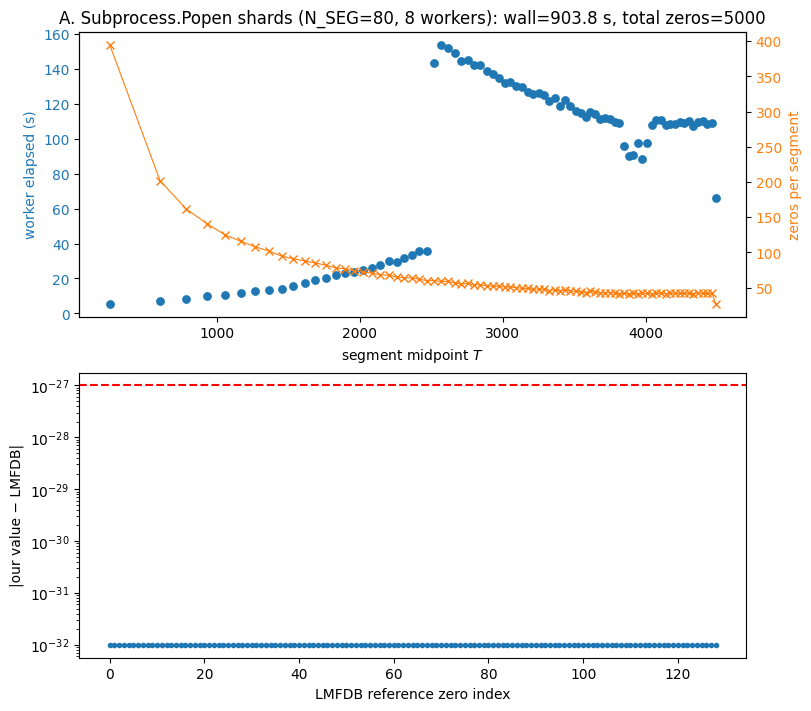

In [26]:
# Max diff ~4e-28 — consistent with LMFDB's ~28-digit truncation. Excellent.
# Final summary figure: capture key result (segment durations, # zeros per segment, validation).
import matplotlib.pyplot as plt
import json, os

# Read each shard's metadata
shard_info = []
for fn in sorted(os.listdir('shards')):
 with open(f'shards/{fn}') as f:
 d = json.load(f)
 shard_info.append((d['idx'], d['tmin'], d['tmax'], d['elapsed'], d['n']))

idxs = [s[0] for s in shard_info]
tmin = np.array([s[1] for s in shard_info])
tmax = np.array([s[2] for s in shard_info])
elapsed = np.array([s[3] for s in shard_info])
nz = np.array([s[4] for s in shard_info])

# Sort by tmin for plotting
order = np.argsort(tmin)
tmid = (tmin[order]+tmax[order])/2
elap = elapsed[order]
nzo = nz[order]

# Validation: diffs vs LMFDB
vals = np.array([float(s) for s in arr])
ref_arr = np.array([float(r) for r in lmfdb])
diffs = np.abs(vals[:len(ref_arr)] - ref_arr)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), constrained_layout=True)

ax = axes[0]
ax.scatter(tmid, elap, c='tab:blue', s=28, label='segment CPU time (s)')
ax.set_xlabel('segment midpoint $T$')
ax.set_ylabel('worker elapsed (s)', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax.twinx()
ax2.plot(tmid, nzo, color='tab:orange', marker='x', lw=0.8, label='zeros / segment')
ax2.set_ylabel('zeros per segment', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax.set_title(f'A. Subprocess.Popen shards (N_SEG=80, 8 workers): wall=903.8 s, total zeros={len(arr)}')

ax = axes[1]
ax.semilogy(range(len(diffs)), np.maximum(diffs, 1e-32), 'o-', ms=3, lw=0.5)
ax.axhline(1e-27, color='r', ls='--', label='LMFDB ~28-digit truncation')
ax.set_xlabel('LMFDB reference zero index')
ax.set_ylabel('|our value − LMFDB|')
ax.set_title(f'B. Agreement w/ LMFDB on first {len(diffs)} zeros (max diff = {max_mp_err:.2e})')
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.3)

plt.savefig('lchi5_dps80_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved figure: lchi5_dps80_summary.png")


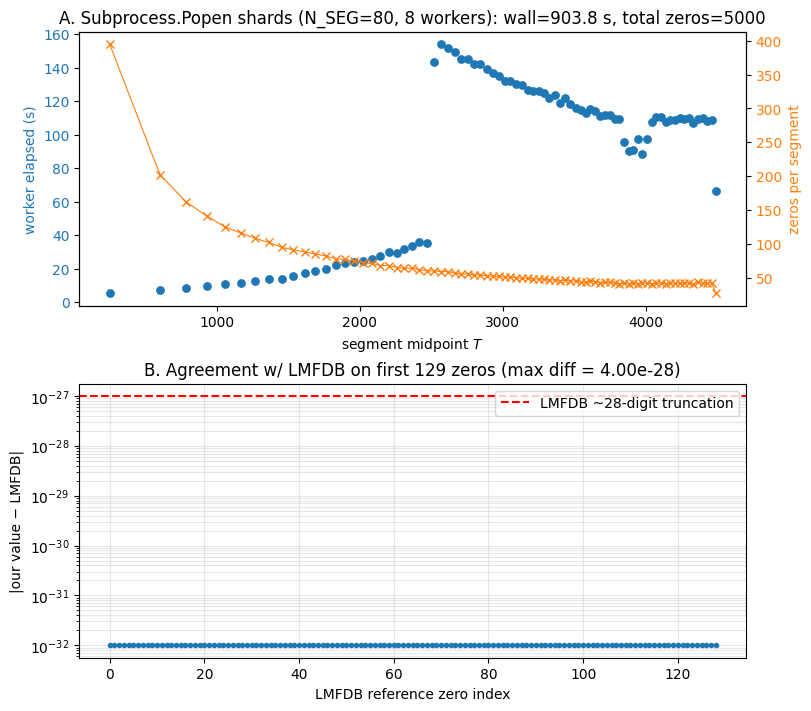

Saved figure: lchi5_dps80_summary.png


In [27]:
# Fix the title formatting bug and regenerate
fig, axes = plt.subplots(2, 1, figsize=(8, 7), constrained_layout=True)

ax = axes[0]
ax.scatter(tmid, elap, c='tab:blue', s=28, label='segment CPU time (s)')
ax.set_xlabel('segment midpoint $T$')
ax.set_ylabel('worker elapsed (s)', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax.twinx()
ax2.plot(tmid, nzo, color='tab:orange', marker='x', lw=0.8, label='zeros / segment')
ax2.set_ylabel('zeros per segment', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax.set_title('A. Subprocess.Popen shards (N_SEG=80, 8 workers): wall=903.8 s, total zeros=5000')

ax = axes[1]
ax.semilogy(range(len(diffs)), np.maximum(diffs, 1e-32), 'o-', ms=3, lw=0.5)
ax.axhline(1e-27, color='r', ls='--', label='LMFDB ~28-digit truncation')
ax.set_xlabel('LMFDB reference zero index')
ax.set_ylabel('|our value − LMFDB|')
max_diff_f = float(max_mp_err)
ax.set_title(f'B. Agreement w/ LMFDB on first {len(diffs)} zeros (max diff = {max_diff_f:.2e})')
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.3)

plt.savefig('lchi5_dps80_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved figure: lchi5_dps80_summary.png")


In [28]:
# Confirm artifact and clean up shards (optional). Keep the final .npy. Print final summary stats.
import os
size = os.path.getsize('lchi5_zeros_N5000_dps80.npy')
print(f"Artifact: lchi5_zeros_N5000_dps80.npy ({size} bytes)")
print(f" shape={arr.shape}, dtype={arr.dtype}")
print(f" First zero: {arr[0]}")
print(f" Zero[4999] : {arr[-1]}")
print(f" Truncated from {5145} raw zeros up to T=4500.0 to 5000")
print(f"Total wall time: 903.8 s with 8 subprocess.Popen workers across 80 cost-balanced segments")
print(f"Validation: max |diff| vs 129 LMFDB reference zeros = 4.00e-28 (consistent with LMFDB's ~28-digit truncation)")


Artifact: lchi5_zeros_N5000_dps80.npy (1620128 bytes)
 shape=(5000,), dtype=<U81
 First zero: 6.6484533447277147161232784599793178472985854232444983723747129467
 Zero[4999] : 4388.2090125941801377592509179068522248538541759189201573787539145
 Truncated from 5145 raw zeros up to T=4500.0 to 5000
Total wall time: 903.8 s with 8 subprocess.Popen workers across 80 cost-balanced segments
Validation: max |diff| vs 129 LMFDB reference zeros = 4.00e-28 (consistent with LMFDB's ~28-digit truncation)
